# Lecture 40. 구간합 빠르게 계산하기

## 0. 목차

1. 구간 합(Interval Sum)
2. 구간 합 빠르게 계산하기 : 문제 설명
3. 구간 합 빠르게 계산하기 : 문제 해결 아이디어
4. 구간 합 빠르게 계산하기 : 코드 예시
5. 코드 피드백 - Gemini
6. 정리 및 회고

## 1. 구간 합 (Interval Sum)

- 구간 합 문제 : 연속적으로 나열된 N개의 수가 있을 때 특정 구간의 모든 수를 합한 값을 계산하는 문제
- 예를 들어 5개의 데이터로 구성된 수열 {10, 20, 30, 40, 50}이 있다고 가정하자.
    - 두 번째 수부터 네 번재 수까지의 합은 20 + 30 + 40 = 90이다.


## 2. 구간 합 빠르게 계산하기 : 문제 설명
- N개의 정수로 구성된 수열이 있다.
- M개의 쿼리(Query) 정보가 주어진다.
    - 각 쿼리는 Left와 Right로 구성된다.
    - 각 쿼릐에 대하여 [Left, Right] 구간에 포함된 데이터들의 합을 출력해야 한다.
- 수행 시간 제한은 O(N+M)이다.

## 3. 구간 합 빠르게 계산하기 : 문제 해결 아이디어

- 접두사 합(Prefix Sum) : 배열의 맨 앞부터 특정 위치까지의 합을 미리 구해 놓는 것
- 접두사 합을 활용한 알고리즘은 다음과 같다.
    - N개의 수 위치 각각에 대하여 접두사 합을 계산하여 P에 저장한다.
    - 매 M개의 쿼리 정보를 확인할 때 구간 합은 P[Right] - P[Left-1]이다.

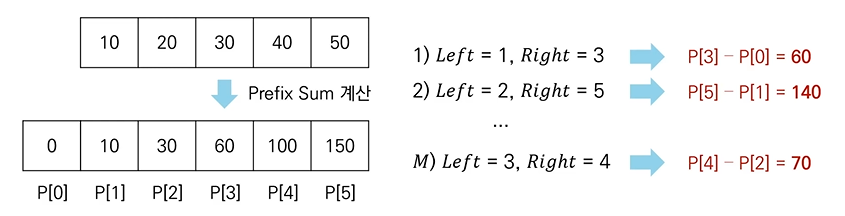

## 4. 구간 합 빠르게 계산하기 : 코드 예시

### 구현 연습

#### 구현 계획

lecture 38 참고
    1) 문제 분석 및 제약 조건 파악
    2) 논리적 의사코드 작성
    3) 자료구조 및 알고리즘 선택

1. 문제 분석 및 제약 조건 파악
    - 구간 합 출력, O(n+m) 으로 시간 복잡도 제약이 있다.

2. 논리적 의사코드 작성
    - 입력으로 리스트 n과 쿼리 개수 m을 받는다.
    for 문 1
    - 접두사 합 리스트 p를 만든다.
    for 문 2
    - m개의 쿼리에 대해서 m[right] - m[left-1]을 계산한다. 
    - for문을 도는 중간에 print 문으로 출력한다. 

3. 자료구조 및 알고리즘
    - 자료구조는 n, p는 리스트, m은 정수로 받는다.
    - 리스트 p는 for문으로 n의 원소를 하나씩 받아서 p에 저장한다. - 시간 복잡도 O(n) / 단, n을 슬라이싱해서 sum을 하면 $O(N^2)$이 되므로 주의
    - m개의 쿼리를 for문으로 m만큼 반복하면서 입력을 받는다.

#### 구현

In [4]:
n = list(map(int, input().split()))
m = int(input())

p = [0]
for i in range(len(n)):
    p.append(p[i] + n[i])


for _ in range(m):
    lef, rig = map(int, input().split())
    print(p[rig] - p[lef-1])

70


#### 구현 중 오류

```
TypeError: 'list' object cannot be interpreted as an integer 오류
```
n을 리스트인데, 숫자로 생각하고 range(n)으로 구현함.
- 변수명 설정 잘하기
마지막 print할 때, p[right] - p[left-1]인데, -1d을 빼먹음.
- test case 해서 알았음.

### 정답 예시

```python
# 데이터의 개수 N과 데이터 입력받기
n = 5
data = [10, 20, 30, 40, 50]

# 접두사 합(Prefix Sum) 배열 계산
sum_value = 0
prefix_sum = [0]
for i in data:
    sum_value += i
    prefix_sum.append(sum_value)

# 구간 합 계산(세 번째 수부터 네 번째 수까지)
left = 3
right = 4
print(prefiX_sum[right] - prefix_sum[left - 1])
```


## 5. 코드 피드백 - Gemini

```

제시해주신 구현 계획과 코드를 꼼꼼히 살펴보았습니다. 구간 합(Prefix Sum)의 핵심 원리를 매우 정확하게 이해하고 계시며, 의사코드와 실제 구현 간의 논리적 연결도 훌륭합니다.

---

### 1. 구현 계획 피드백

* **잘한 점:**
    * **시간 복잡도 고려:** $O(N^2)$이 되는 슬라이싱(`sum(arr[left:right])`) 방식을 피해야 한다는 점을 명확히 인지하고 계획한 것이 매우 좋습니다. 이는 구간 합 문제를 푸는 가장 중요한 이유입니다.
    * **논리적 단계:** 문제 분석 → 의사코드 → 자료구조 선정 순서로 사고하는 방식은 실제 코딩 테스트에서 오류를 줄이는 아주 바람직한 습관입니다.
* **보완할 점:**
    * **인덱스 경계값 처리:** 의사코드 단계에서 `p[left-1]`에 접근할 때 `left`가 1인 경우(`left-1 = 0`)에 대한 처리가 필요합니다. 작성하신 코드에서는 `p` 리스트를 `[0]`으로 초기화함으로써 이 문제를 깔끔하게 해결했는데, 이런 세부 사항을 계획 단계에서 "0번 인덱스는 0으로 초기화하여 인덱스 에러 방지"라고 명시하면 더욱 완벽합니다.

### 2. 코드 피드백

* **잘한 점:**
    * **공간 효율성:** `p = [0]`으로 시작하여 `p[i] + n[i]`를 더해가는 방식은 별도의 변수 없이 깔끔하고 효율적입니다.
    * **입력 방식:** `map`을 활용한 입력 처리는 파이썬에서 매우 표준적이고 좋은 방식입니다.
* **수정 및 제언:**
    * **가독성:** 현재 코드에서 `lef, rig` 변수명도 좋지만, 관습적으로 `l, r` 또는 `left, right`를 많이 사용합니다.
    * **입력 시 주의사항:** 만약 `input().split()`의 첫 번째 줄이 `N(데이터 개수)`과 `M(쿼리 개수)`을 동시에 받는 문제라면 `n, m = map(int, input().split())` 형태로 수정해야 할 수 있습니다. 문제의 입력 형식에 따라 유연하게 대응해 보세요.



### 3. 코드 비교 및 요약

작성하신 코드는 정답 코드와 논리적으로 완전히 동일하며, 오히려 **입력을 사용자로부터 받는 실전적인 형태**로 더 잘 구현되어 있습니다.

**팁:** 구간 합의 개념을 시각화하면 다음과 같습니다.
> 구간 $[L, R]$의 합 = (인덱스 0부터 $R$까지의 합) - (인덱스 0부터 $L-1$까지의 합)

이 원리를 완벽히 구현하셨습니다. 앞으로는 입력값의 범위가 매우 클 때(예: $N=100,000$ 이상), `input()` 대신 `sys.stdin.readline`을 사용하여 입력 속도를 최적화하는 습관을 들이면 더욱 좋습니다.

---
**추가로 궁금한 점이 있으신가요?** 예를 들어, 입력 데이터가 매우 많을 때 속도를 높이는 `sys.stdin.readline`의 활용법에 대해 더 알아보고 싶으신가요?

```

요약
1. 엣지 케이스 처리에 대해서 명시하기
2. 가독성 - 변수 설정


## 6. 정리 및 회고

### 순서

1. 구간 합(Interval Sum)
2. 구간 합 빠르게 계산하기 : 문제 설명
3. 구간 합 빠르게 계산하기 : 문제 해결 아이디어
4. 구간 합 빠르게 계산하기 : 코드 예시
5. 코드 피드백 - Gemini
6. 정리 및 회고

### 키워드
구간 합, 접두사 합

### 회고
1. 구현 계획, 구현 모두 잘 해냈음.
2. 엣지 케이스에 대해서는 생각하지 못 함.
